# Performance and Risk Tear Sheets

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Avinashmhm/QuantProjects/blob/main/Tear%20Sheets/tear_sheets.ipynb)

Standalone performance and risk tear sheets for six individual series, each measured on its own (no benchmark comparison): SPY, the S&P 500 index (^GSPC), NVDA, AMD, AAPL, and MU.

Each tear sheet is built from real Yahoo Finance adjusted-close data (2014 to 2024) and shows the growth of one dollar on a log scale, the drawdown-from-peak underwater plot, a rolling six-month Sharpe ratio, a monthly-return heatmap, and the return distribution against a normal curve. A combined statistics table at the end lists CAGR, volatility, Sharpe, Sortino, Calmar, maximum drawdown, historical VaR and Expected Shortfall, and a Newey-West (HAC) significance test for each series.

The notebook runs with no API keys. If the network is unavailable it falls back to a clearly labeled synthetic dataset so it always runs top to bottom, and it prints which data path is active.

## 1. Setup

Pinned installs (skipped when already present), imports, a random seed, one CONFIG block listing the six series, and a single plotting theme. The inline backend is forced so figures embed when the notebook runs headless.

In [1]:
import importlib.util, subprocess, sys
PINNED = ["numpy==1.26.4","pandas==2.1.4","scipy==1.11.4","matplotlib==3.8.4",
          "seaborn==0.13.2","statsmodels==0.14.1"]
_missing = [p for p in PINNED if importlib.util.find_spec(p.split("==")[0]) is None]
if _missing:
    print("Installing:", ", ".join(_missing))
    subprocess.run([sys.executable,"-m","pip","install","-q",*_missing], check=False)
else:
    print("All pinned packages present.")

All pinned packages present.


In [2]:
import os, socket, json, time, random, warnings, urllib.request, urllib.parse, datetime as dt
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib
try:
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy import stats as sstats
import statsmodels.api as sm
from IPython.display import display

random.seed(42); np.random.seed(42); socket.setdefaulttimeout(30)
TD = 252
CONFIG = {
    # (display name, Yahoo symbol, output slug)
    "SERIES": [("SPY (S&P 500 ETF)", "SPY", "SPY"),
               ("S&P 500 Index", "^GSPC", "SP500"),
               ("NVIDIA (NVDA)", "NVDA", "NVDA"),
               ("AMD", "AMD", "AMD"),
               ("Apple (AAPL)", "AAPL", "AAPL"),
               ("Micron (MU)", "MU", "MU")],
    "START": "2014-01-01", "END": "2024-12-31",
    "RF": 0.02,            # flat annual risk-free used for Sharpe (short rate averaged over the window)
    "ROLL_WINDOW": 126, "TRADING_DAYS": TD, "VAR_CONF": 0.95,
    "OUTPUT_DIR": os.environ.get("QUANT_OUTPUT_DIR")
                  or ("/content" if importlib.util.find_spec("google.colab") else "outputs"),
}
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
PAL = {"line":"#1f4e79","neg":"#c62828","acc":"#e8833a","neu":"#4f5b66"}
sns.set_theme(style="whitegrid", context="notebook")
matplotlib.rcParams.update({"figure.dpi":110,"savefig.dpi":150,"axes.titleweight":"bold",
                            "figure.facecolor":"white","axes.facecolor":"white","legend.frameon":False})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Series:", ", ".join(s[1] for s in CONFIG["SERIES"]))
print("Output dir:", CONFIG["OUTPUT_DIR"])

Series: SPY, ^GSPC, NVDA, AMD, AAPL, MU
Output dir: /Users/avinashmahadevan/Desktop/QuantProjects/Tear Sheets


## 2. Data, metrics, and the tear-sheet renderer

Prices come from Yahoo's keyless JSON chart API (more reliable than the yfinance scraper), with a synthetic fallback if the network is unavailable. The metric functions and the five-panel renderer below are applied identically to every series, so each tear sheet is directly comparable even though none of them share a chart.

In [3]:
def offline():
    return bool(os.environ.get("QUANT_OFFLINE"))

def synth_price(sym, start, end, i=0):
    rng = np.random.default_rng(abs(hash(sym)) % (2**32))
    dates = pd.bdate_range(start, end); n = len(dates)
    mkt = rng.normal(0.09/TD, 0.16/np.sqrt(TD), n); shock = mkt - mkt.mean()
    beta = 1.0 + 0.3*i; drift = 0.08/TD
    ret = drift + beta*shock + rng.normal(0, 0.18/np.sqrt(TD), n)
    return pd.Series(100*np.exp(np.cumsum(ret)), index=dates, name=sym)

def yahoo_adjclose(sym, start, end, tries=3):
    p1 = int(time.mktime(dt.date.fromisoformat(start).timetuple()))
    p2 = int(time.mktime(dt.date.fromisoformat(end).timetuple()))
    url = (f"https://query1.finance.yahoo.com/v8/finance/chart/{urllib.parse.quote(sym)}"
           f"?period1={p1}&period2={p2}&interval=1d&events=div%2Csplit")
    for k in range(tries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent":"Mozilla/5.0 (Macintosh) research"})
            j = json.loads(urllib.request.urlopen(req).read().decode("utf-8"))
            res = j["chart"]["result"][0]
            idx = pd.to_datetime(res["timestamp"], unit="s").normalize()
            s = pd.Series(res["indicators"]["adjclose"][0]["adjclose"], index=idx, name=sym).dropna()
            return s[~s.index.duplicated(keep="last")]
        except Exception as exc:
            print(f"  {sym} attempt {k+1} failed: {exc}"); time.sleep(1.0*(k+1))
    raise RuntimeError(sym)

def get_price(sym, i):
    if offline():
        return synth_price(sym, CONFIG["START"], CONFIG["END"], i)
    try:
        s = yahoo_adjclose(sym, CONFIG["START"], CONFIG["END"])
        if len(s) > 200:
            return s
        raise RuntimeError("too few rows")
    except Exception as exc:
        print(f"  {sym}: live failed ({exc}); using synthetic fallback")
        return synth_price(sym, CONFIG["START"], CONFIG["END"], i)

RFD = CONFIG["RF"] / TD
def cum(r): return (1+r).cumprod()
def cagr(r): y=len(r)/TD; return cum(r).iloc[-1]**(1/y)-1
def vol(r): return r.std(ddof=1)*np.sqrt(TD)
def sharpe(r, rf=RFD): ex=r-rf; return ex.mean()/ex.std(ddof=1)*np.sqrt(TD)
def ddown(r): w=cum(r); return w/w.cummax()-1
def mdd(r): return ddown(r).min()
def calmar(r): m=mdd(r); return cagr(r)/abs(m) if m<0 else np.nan
def downdev(r): d=np.minimum(r,0.0); return np.sqrt((d**2).mean())*np.sqrt(TD)
def sortino(r, rf=RFD): x=downdev(r); return (r-rf).mean()*TD/x if x>0 else np.nan
def varh(r,c=0.95): return -r.quantile(1-c)
def cvarh(r,c=0.95): q=r.quantile(1-c); t=r[r<=q]; return -t.mean()
def hit(r): return (r>0).mean()
def longdd(r):
    u=ddown(r)<0; best=cur=0
    for x in u: cur=cur+1 if x else 0; best=max(best,cur)
    return int(best)
def hac_t(r, lags=21):
    y=np.asarray(r.dropna(),float)
    m=sm.OLS(y,np.ones((len(y),1))).fit(cov_type="HAC",cov_kwds={"maxlags":lags})
    return float(m.tvalues[0]), float(m.pvalues[0])
def roll_sharpe(r,w,rf=RFD): ex=r-rf; return ex.rolling(w).mean()/ex.rolling(w).std(ddof=1)*np.sqrt(TD)
def monthly(r):
    m=r.resample("M").apply(lambda s:(1+s).prod()-1); d=m.to_frame("ret")
    d["Y"],d["M"]=d.index.year,d.index.month; return d.pivot(index="Y",columns="M",values="ret")

def render_tear_sheet(name, r, outpath):
    w=CONFIG["ROLL_WINDOW"]; wealth,dd,rs,heat = cum(r),ddown(r),roll_sharpe(r,w),monthly(r)
    fig = plt.figure(figsize=(15,12)); gs = gridspec.GridSpec(3,2,height_ratios=[1.1,1,1],hspace=0.42,wspace=0.22)
    a1=fig.add_subplot(gs[0,:]); a1.plot(wealth.index,wealth,color=PAL["line"]); a1.set_yscale("log")
    a1.set_title("Growth of $1 (log scale)"); a1.set_ylabel("Value of $1")
    a2=fig.add_subplot(gs[1,0]); a2.fill_between(dd.index,dd.values,0,color=PAL["neg"],alpha=0.35)
    a2.plot(dd.index,dd.values,color=PAL["neg"],lw=1); a2.yaxis.set_major_formatter(PercentFormatter(1.0))
    a2.set_title("Underwater Plot (drawdown from peak)"); a2.set_ylabel("Drawdown")
    a3=fig.add_subplot(gs[1,1]); a3.plot(rs.index,rs.values,color=PAL["acc"]); a3.axhline(0,color="#888",lw=0.8)
    a3.set_title("Rolling Sharpe (126d, approx 6 months)"); a3.set_ylabel("Annualized Sharpe")
    a4=fig.add_subplot(gs[2,0]); sns.heatmap(heat,cmap="RdYlGn",center=0,cbar_kws={"shrink":0.8},linewidths=0.4,ax=a4)
    a4.set_title("Monthly Returns (Year x Month)"); a4.set_xlabel("Month"); a4.set_ylabel("Year")
    a5=fig.add_subplot(gs[2,1]); a5.hist(r,bins=60,density=True,color=PAL["line"],alpha=0.6,label="Daily returns")
    xs=np.linspace(r.min(),r.max(),200); a5.plot(xs,sstats.norm.pdf(xs,r.mean(),r.std(ddof=1)),color=PAL["neg"],lw=1.5,label="Normal")
    a5.set_title("Return Distribution vs Normal"); a5.set_xlabel("Daily return"); a5.legend(fontsize=8)
    fig.suptitle(f"{name}: Performance and Risk Tear Sheet ({r.index.min().date()} to {r.index.max().date()})",
                 fontsize=15, weight="bold", y=0.995)
    fig.text(0.99,0.005,"Real data: Yahoo Finance adjusted close. Sharpe uses a flat 2% risk-free.",
             ha="right", fontsize=7, color=PAL["neu"])
    fig.savefig(outpath, bbox_inches="tight", dpi=150)
    return fig

def stat_row(name, sym, r):
    t,p = hac_t(r)
    return {"Series":name,"Ticker":sym,"CAGR":cagr(r),"Ann.Vol":vol(r),"Sharpe":sharpe(r),
            "Sortino":sortino(r),"Calmar":calmar(r),"MaxDrawdown":mdd(r),"HitRate":hit(r),
            "VaR95":varh(r),"CVaR95":cvarh(r),"Skew":float(sstats.skew(r.dropna())),
            "Kurtosis":float(sstats.kurtosis(r.dropna())),"LongestDD_days":longdd(r),"HAC_t":t,"HAC_p":p}

print("Helpers ready. Data path:", "SYNTHETIC (offline)" if offline() else "LIVE Yahoo chart API")

Helpers ready. Data path: LIVE Yahoo chart API


## 3. The six tear sheets

Each series is fetched, rendered, saved as a PNG, and displayed below. A single dollar invested in each is tracked on a log scale, so a straight rising line means steady compounding and a steep section means a fast run.

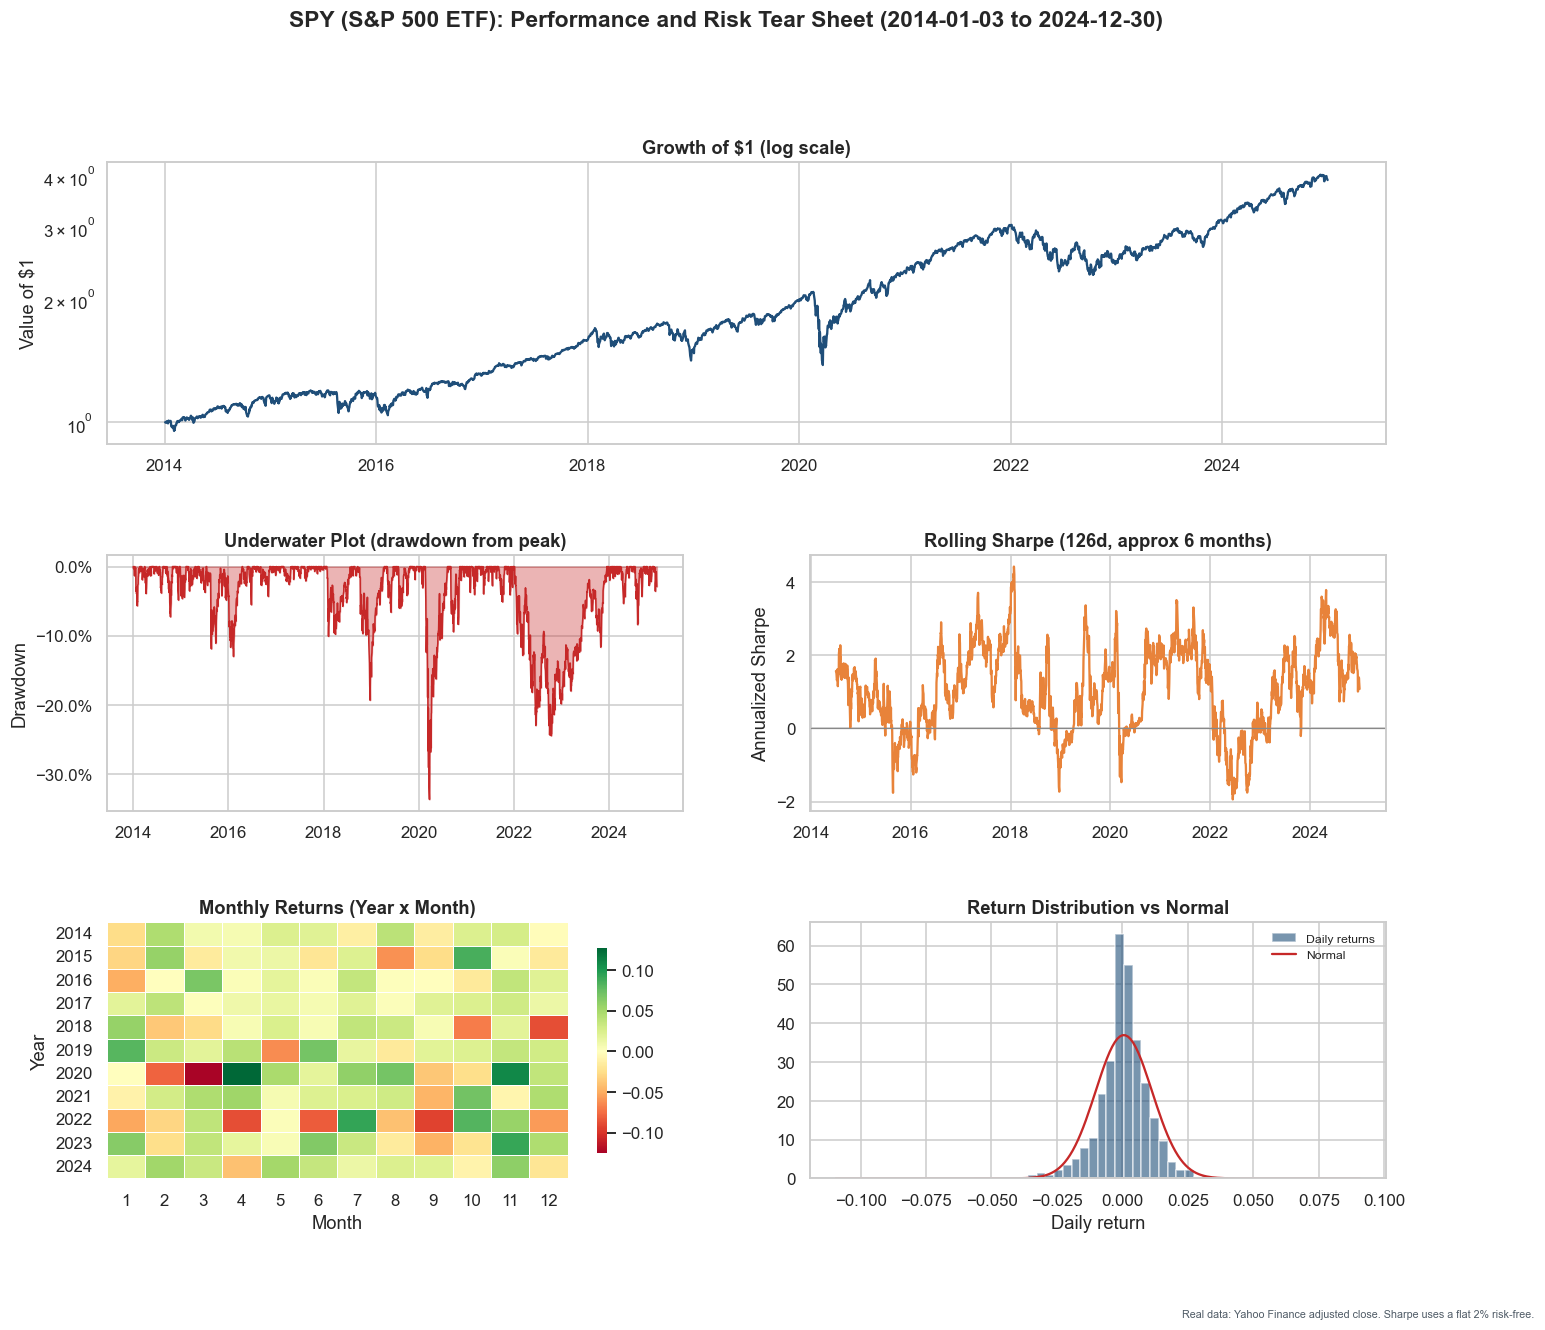

SPY    2014-01-02 to 2024-12-30  CAGR  13.2%  Sharpe 0.69  MaxDD -33.7%  ->  /Users/avinashmahadevan/Desktop/QuantProjects/Tear Sheets/SPY_tear_sheet.png


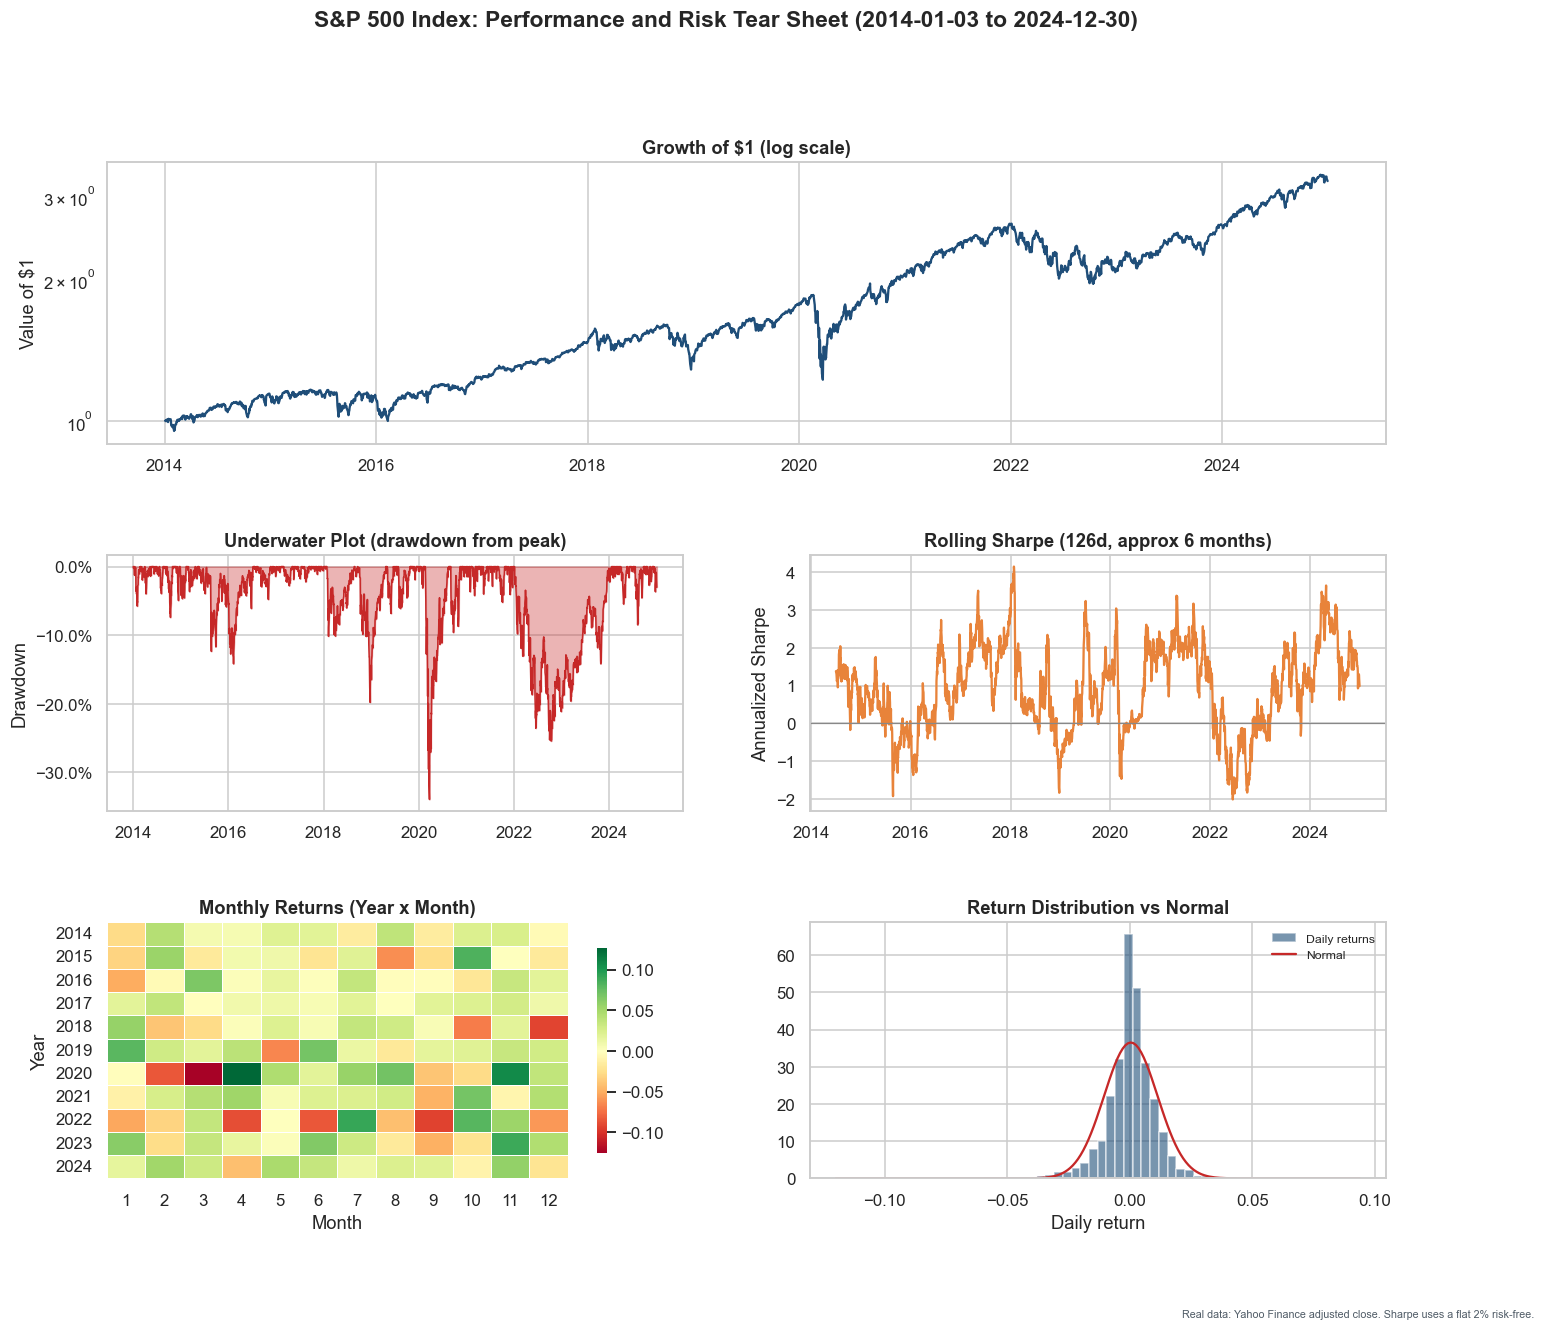

SP500  2014-01-02 to 2024-12-30  CAGR  11.3%  Sharpe 0.59  MaxDD -33.9%  ->  /Users/avinashmahadevan/Desktop/QuantProjects/Tear Sheets/SP500_tear_sheet.png


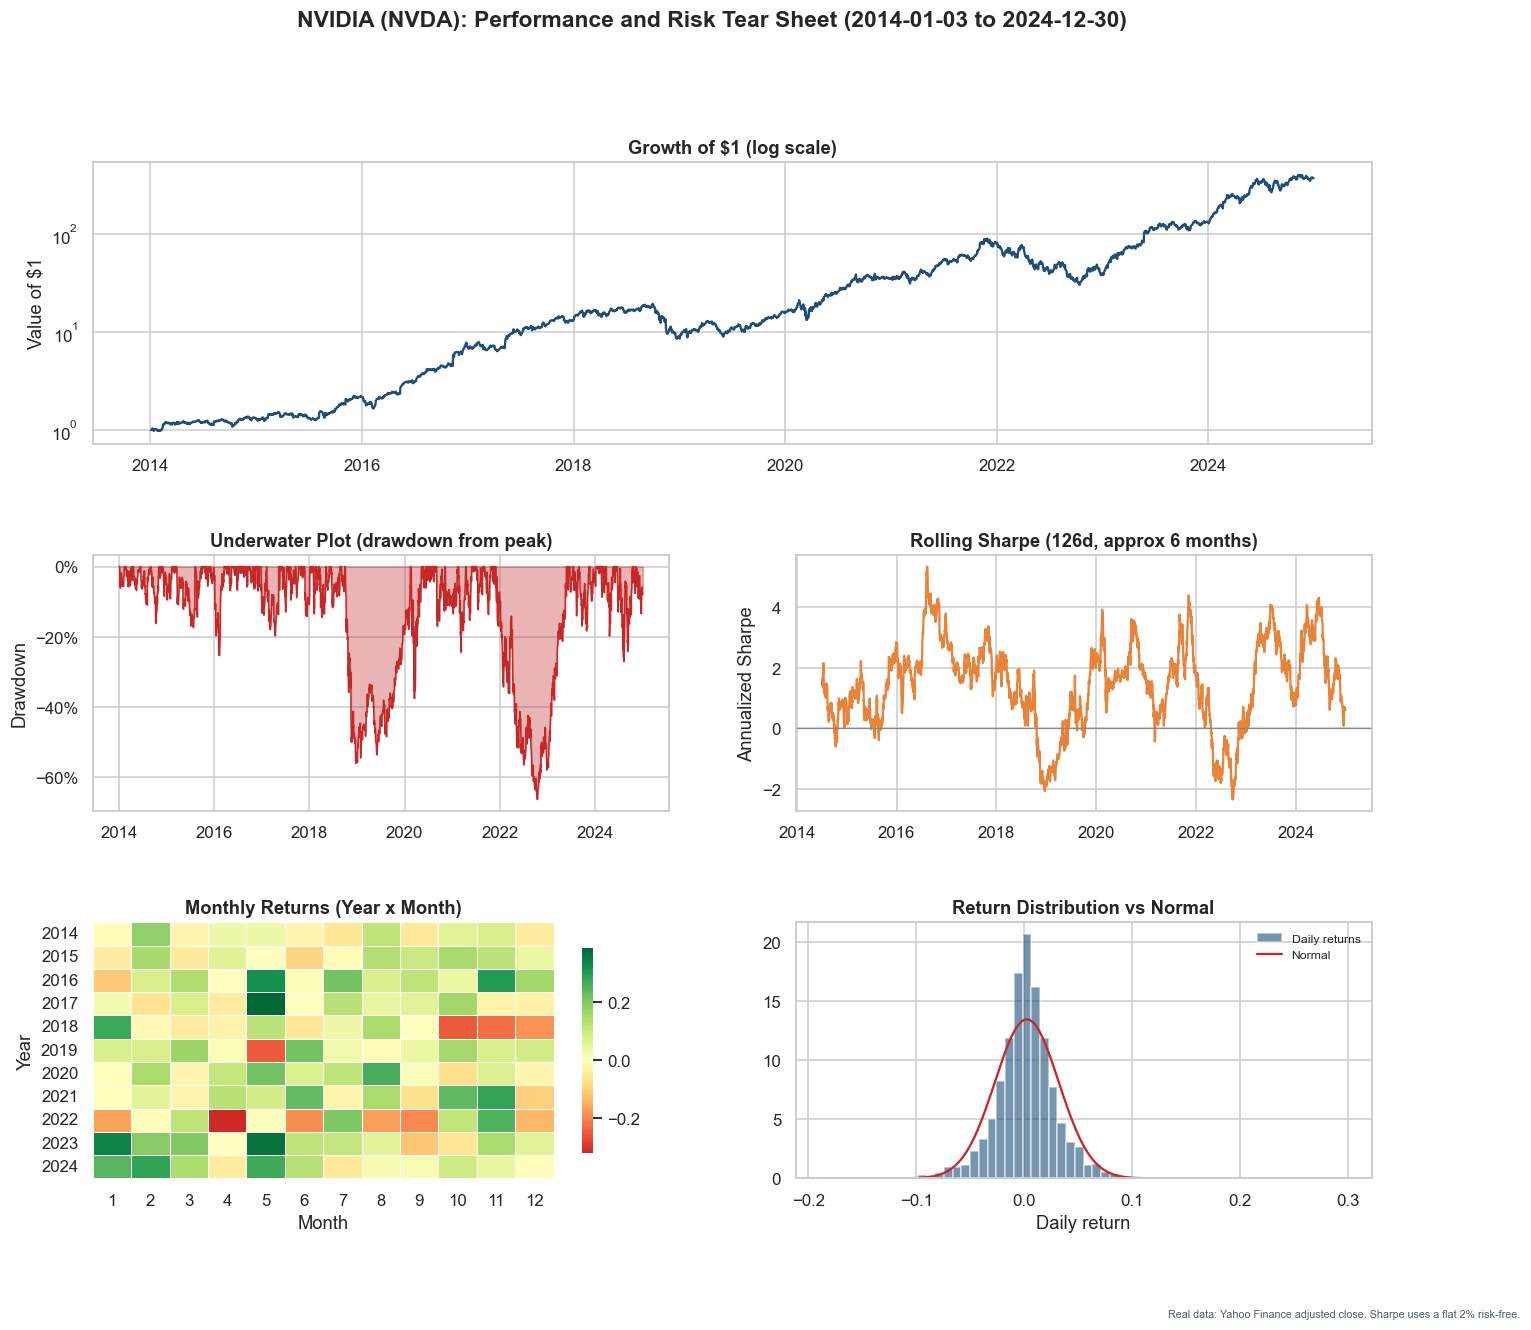

NVDA   2014-01-02 to 2024-12-30  CAGR  71.3%  Sharpe 1.34  MaxDD -66.3%  ->  /Users/avinashmahadevan/Desktop/QuantProjects/Tear Sheets/NVDA_tear_sheet.png


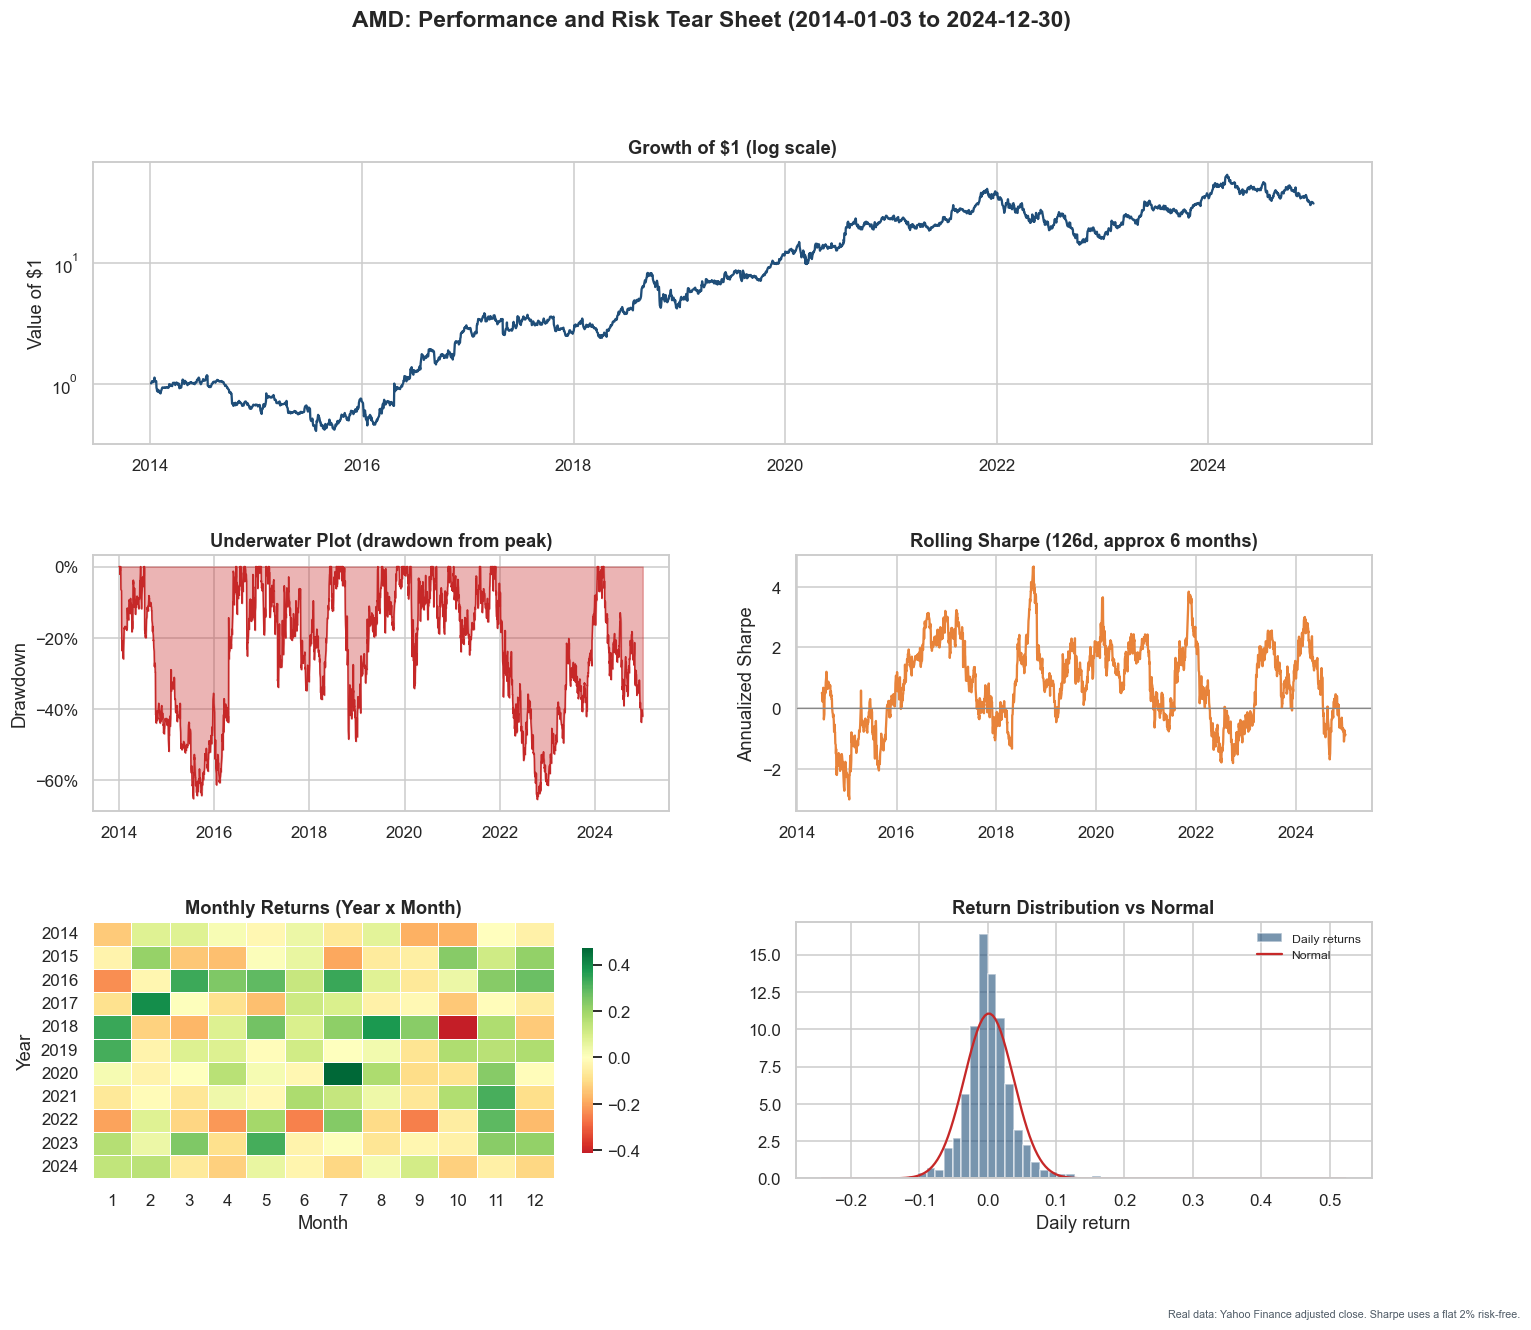

AMD    2014-01-02 to 2024-12-30  CAGR  36.7%  Sharpe 0.79  MaxDD -65.4%  ->  /Users/avinashmahadevan/Desktop/QuantProjects/Tear Sheets/AMD_tear_sheet.png


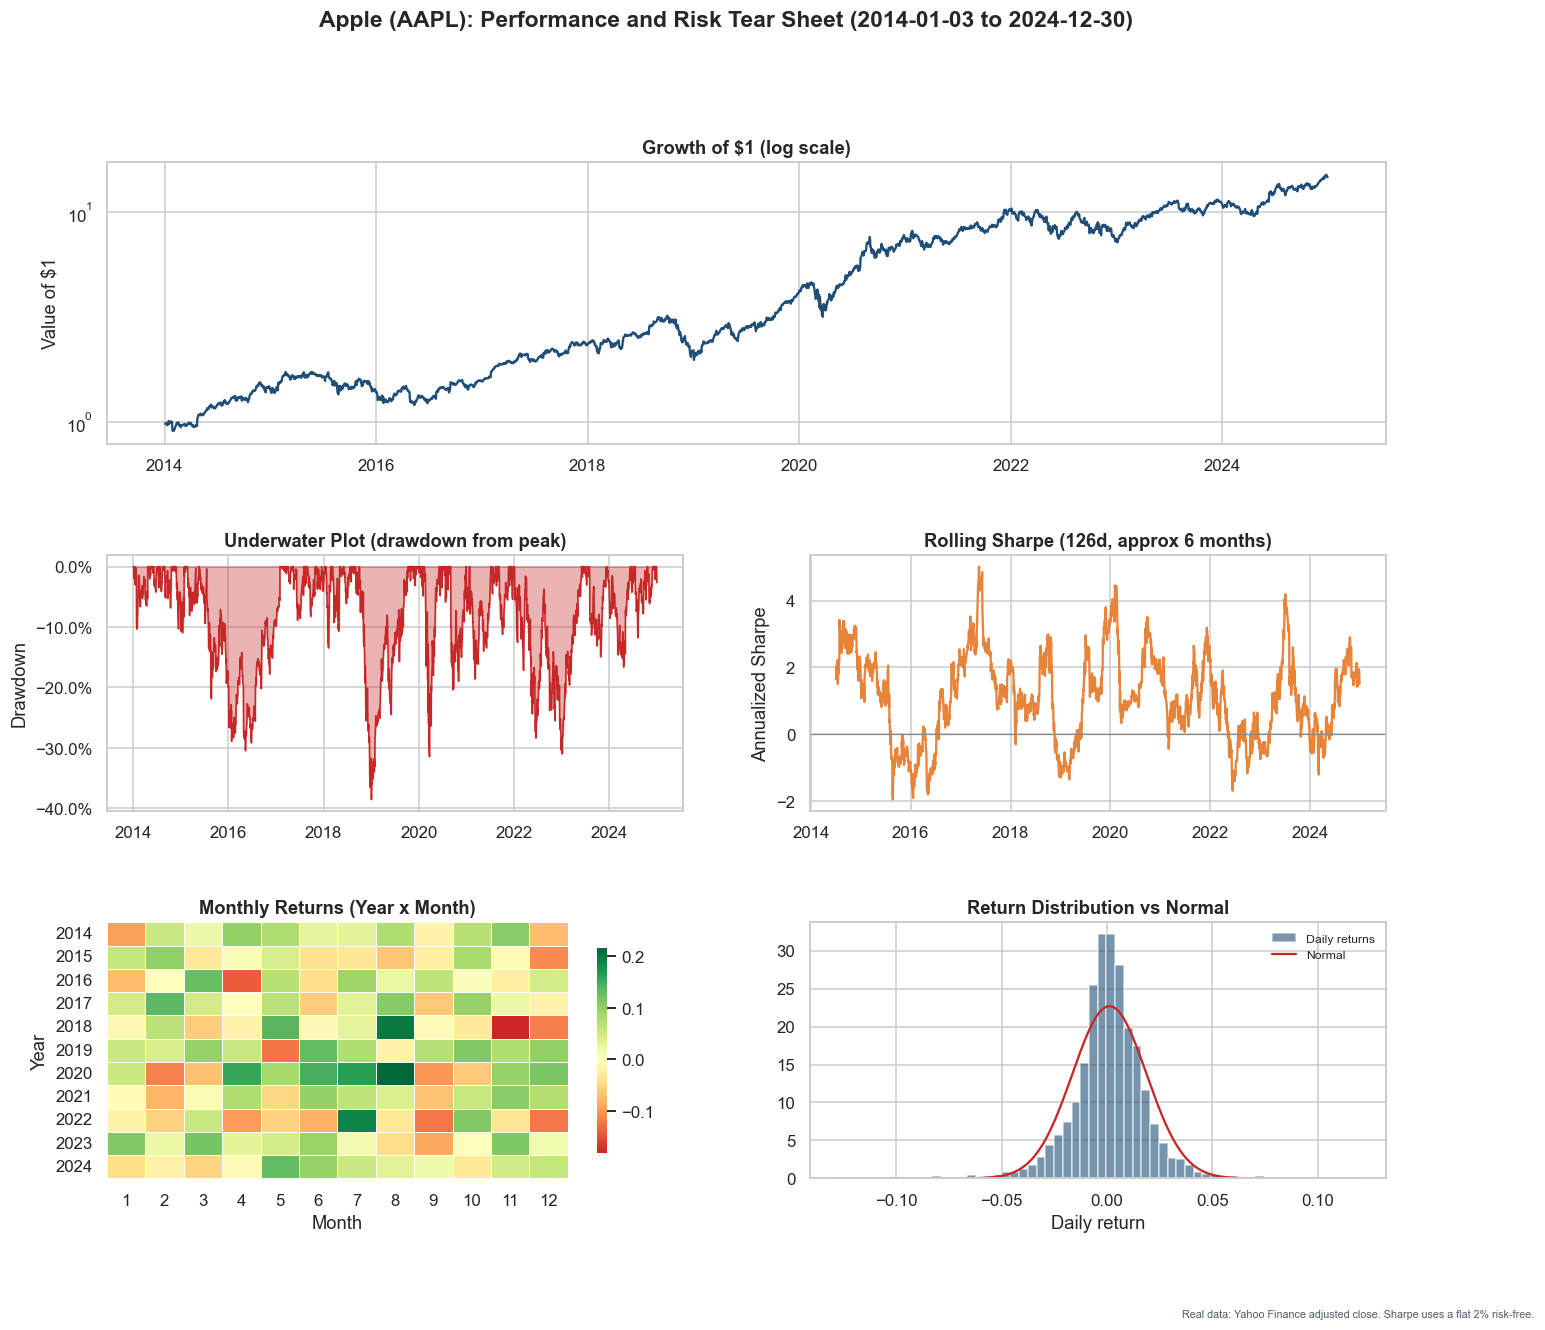

AAPL   2014-01-02 to 2024-12-30  CAGR  27.7%  Sharpe 0.94  MaxDD -38.5%  ->  /Users/avinashmahadevan/Desktop/QuantProjects/Tear Sheets/AAPL_tear_sheet.png


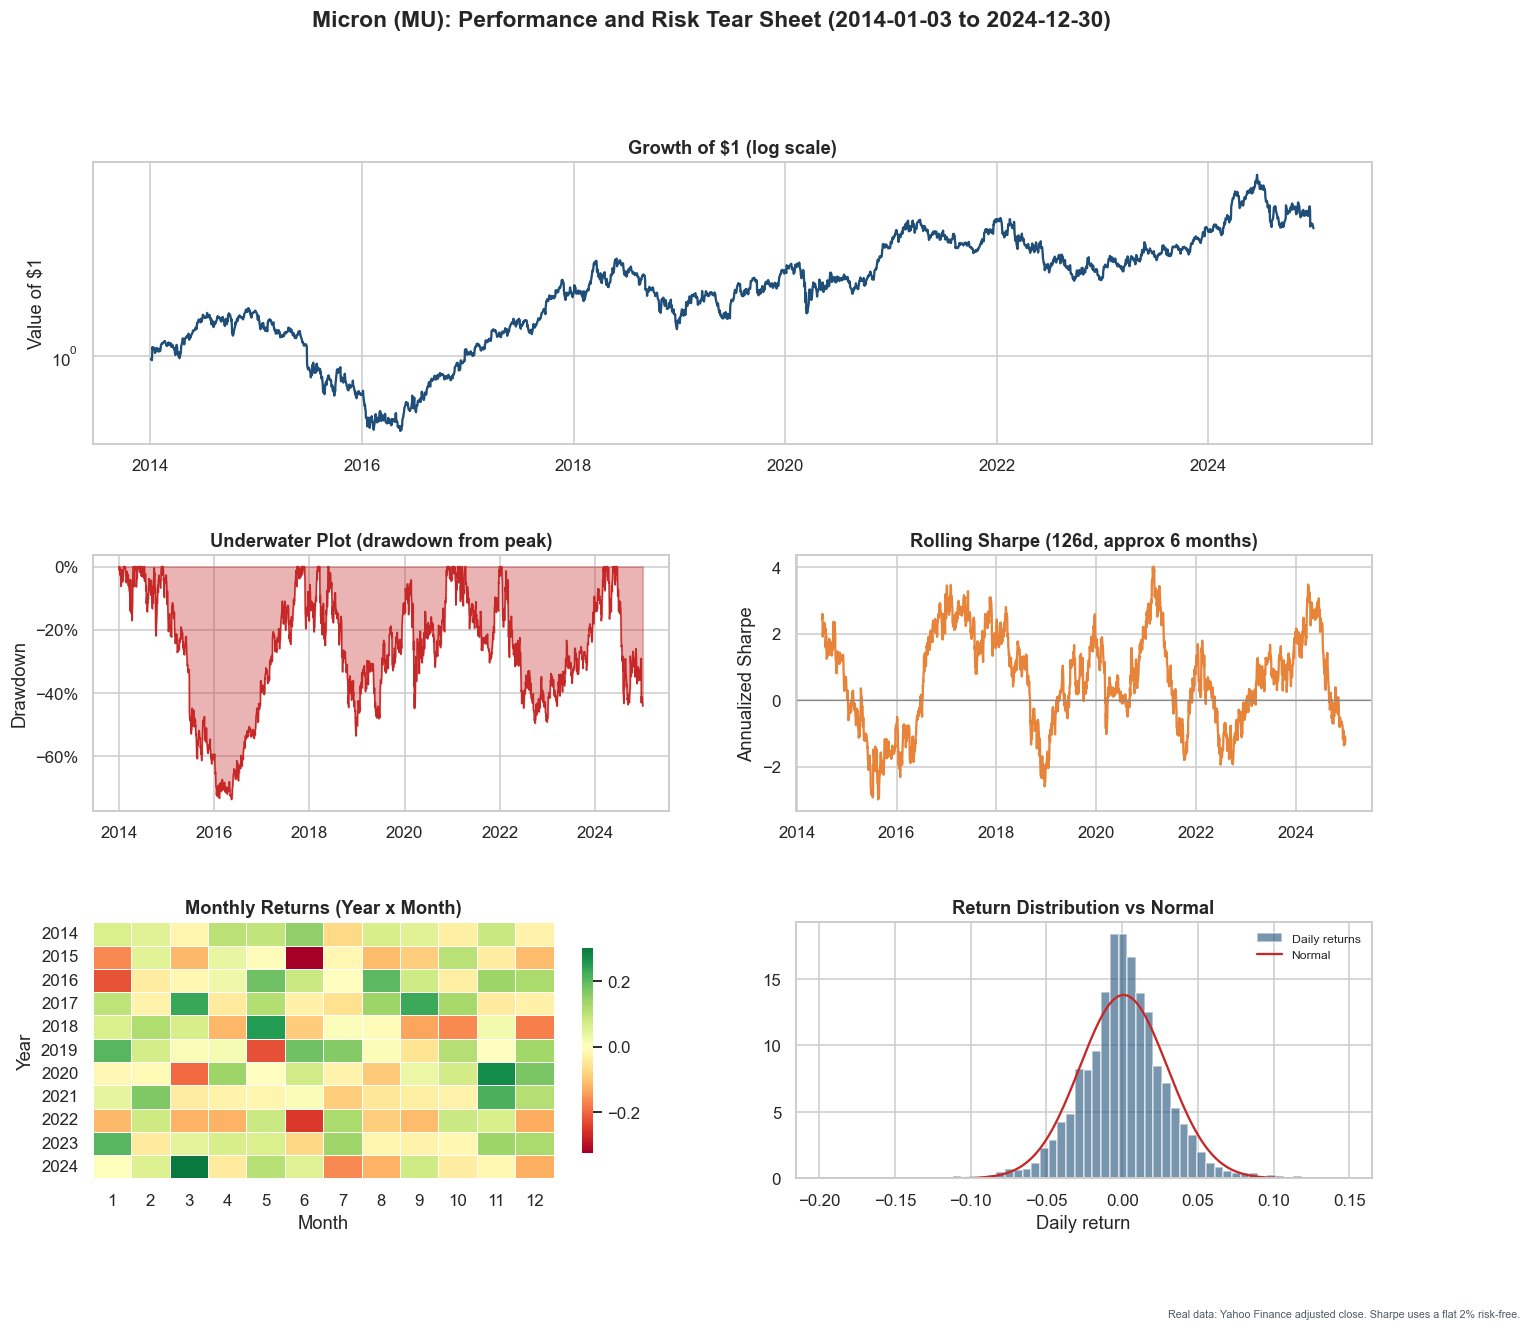

MU     2014-01-02 to 2024-12-30  CAGR  13.5%  Sharpe 0.46  MaxDD -73.8%  ->  /Users/avinashmahadevan/Desktop/QuantProjects/Tear Sheets/MU_tear_sheet.png


In [4]:
rows = []
for i, (name, sym, slug) in enumerate(CONFIG["SERIES"]):
    px = get_price(sym, i); r = px.pct_change().dropna()
    outpath = os.path.join(CONFIG["OUTPUT_DIR"], f"{slug}_tear_sheet.png")
    fig = render_tear_sheet(name, r, outpath)
    display(fig); plt.close(fig)
    rows.append(stat_row(name, sym, r))
    print(f"{slug:6s} {px.index.min().date()} to {px.index.max().date()}  "
          f"CAGR {cagr(r):6.1%}  Sharpe {sharpe(r):4.2f}  MaxDD {mdd(r):6.1%}  ->  {outpath}")

## 4. Combined statistics

One table with the headline numbers for all six series. Sharpe and Sortino use a flat 2% annual risk-free. The HAC_t column is the Newey-West t-statistic that the mean daily return differs from zero (values above about 2 are significant at the 5% level).

In [5]:
stats = pd.DataFrame(rows).set_index("Series")
csv_path = os.path.join(CONFIG["OUTPUT_DIR"], "tear_sheet_stats.csv")
stats.to_csv(csv_path)
display(stats.round(4))
print("Saved combined stats to", csv_path)
best = stats["Sharpe"].idxmax(); worst = stats["MaxDrawdown"].idxmin()
print(f"\nHighest Sharpe: {best} ({stats.loc[best,'Sharpe']:.2f}).  "
      f"Deepest drawdown: {worst} ({stats.loc[worst,'MaxDrawdown']:.1%}).")

,Ticker,CAGR,Ann.Vol,Sharpe,Sortino,Calmar,MaxDrawdown,HitRate,VaR95,CVaR95,Skew,Kurtosis,LongestDD_days,HAC_t,HAC_p
Series,,,,,,,,,,,,,,,
SPY (S&P 500 ETF),SPY,0.1321,0.1714,0.6934,0.9684,0.3917,-0.3372,0.5503,0.0163,0.0263,-0.5593,13.0558,488,3.0589,0.0022
S&P 500 Index,^GSPC,0.1126,0.1734,0.5870,0.8186,0.3318,-0.3392,0.5405,0.0164,0.0265,-0.5323,14.9231,512,2.6849,0.0073
NVIDIA (NVDA),NVDA,0.7129,0.4697,1.3367,2.0920,1.0747,-0.6634,0.5427,0.0430,0.0631,0.6490,8.8497,373,4.7707,0.0000
AMD,AMD,0.3673,0.5726,0.7922,1.2356,0.5612,-0.6545,0.5007,0.0520,0.0762,1.2166,18.5985,535,2.8835,0.0039
Apple (AAPL),AAPL,0.2769,0.2791,0.9442,1.3891,0.7190,-0.3852,0.5333,0.0265,0.0400,-0.0116,5.5553,426,3.5243,0.0004
Micron (MU),MU,0.1352,0.4594,0.4627,0.6722,0.1832,-0.7380,0.5127,0.0444,0.0630,-0.0188,3.3708,706,1.8512,0.0641


Saved combined stats to /Users/avinashmahadevan/Desktop/QuantProjects/Tear Sheets/tear_sheet_stats.csv

Highest Sharpe: NVIDIA (NVDA) (1.34).  Deepest drawdown: Micron (MU) (-73.8%).


## 5. Notes and limitations

- These are single-series tear sheets. Each one describes one asset or index on its own, with no benchmark line and no relative-performance statistics.
- Sharpe and Sortino use a flat 2% annual risk-free rate. This is close to the average 3-month Treasury yield over 2014 to 2024 and keeps the notebook runnable without a live rate feed.
- The S&P 500 index series (^GSPC) is price only, so it excludes dividends. SPY is a total-return series (dividends reinvested through the adjusted close), which is why SPY shows a higher CAGR than the index over the same window.
- Yahoo adjusted closes are revised for splits and dividends after the fact, so they are not a point-in-time record of what a trader saw on the day.
- Past compounding does not predict future returns. The individual stocks here are large, well-known names whose past paths reflect outcomes that were not knowable in advance.